# Laboratorium: Klasyfikacja danych niezrównoważonych

W tym laboratorium wcielisz się w rolę analityka danych pracującego dla popularnej aplikacji randkowej `Habibi`. Twoim celem będzie przewidywanie, czy dwoje ludzi przypadnie sobie do gustu (tzw. "match"). Niestety "match" to zdarzenie rzadkie, przez co Twój poprzednik, Link**In-owy influencer AI, nie podołał zadaniu i model generował tylko losowe lub większościowe predykcje.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline

from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

from sklearn.manifold import TSNE
from catboost import CatBoostClassifier


## CZĘŚĆ 1: Walka z dysproporcją klas


### Zadanie 1.1: Pobranie Danych i EDA
Pobranie zbioru danych oraz analiza rozkładu klas oraz sprawdzenie korelacji danych

In [3]:
# Pobranie danych
df = pd.read_csv('speeddating.csv')
print(f"Kształt danych: {df.shape}")

#usuniecie znakow dziwnych 
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].astype(str).str.replace(r"^b['\"]|['\"]$", "", regex=True)
    df[col] = df[col].replace('nan', np.nan)

df['match'] = df['match'].astype(int)


Kształt danych: (8378, 123)


/var/folders/8w/symc1_g91w3fxs2jbphlbxg40000gn/T/ipykernel_56162/1544608019.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']).columns:


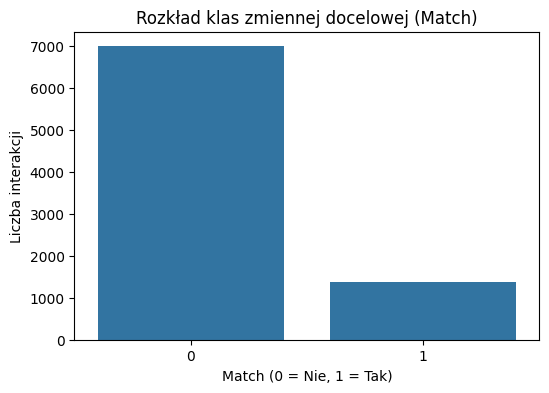

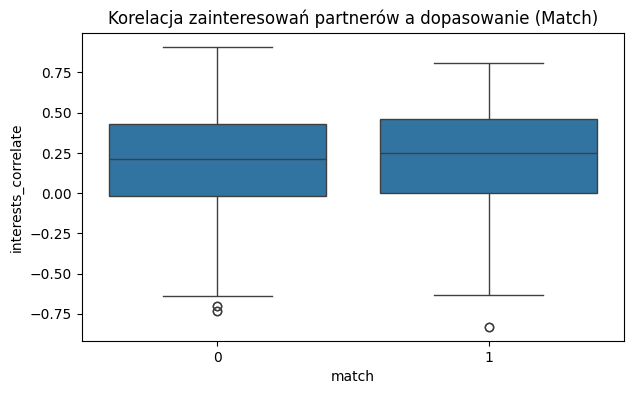

In [4]:
# Rozkład zmiennej docelowej (match)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='match')
plt.title("Rozkład klas zmiennej docelowej (Match)")
plt.xlabel("Match (0 = Nie, 1 = Tak)")
plt.ylabel("Liczba interakcji")
plt.show()

# Korelacja zainteresowań a match
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='match', y='interests_correlate')
plt.title("Korelacja zainteresowań partnerów a dopasowanie (Match)")
plt.show()

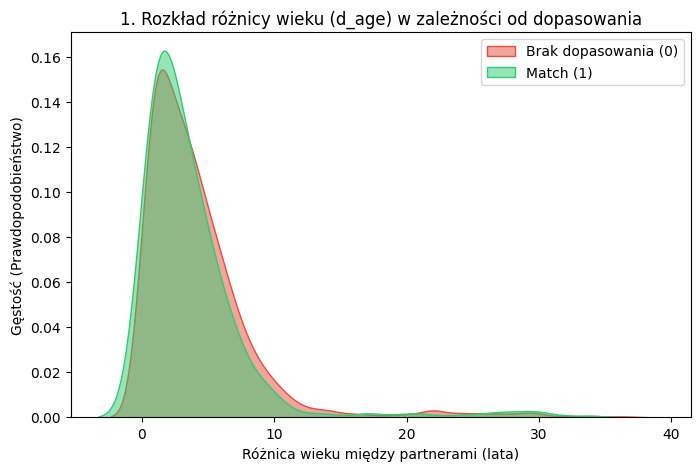

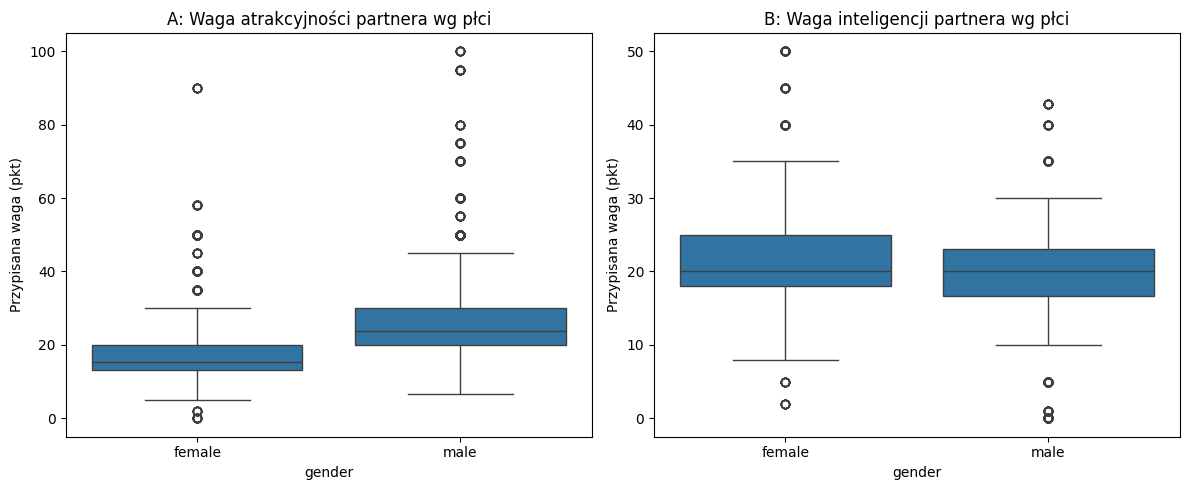

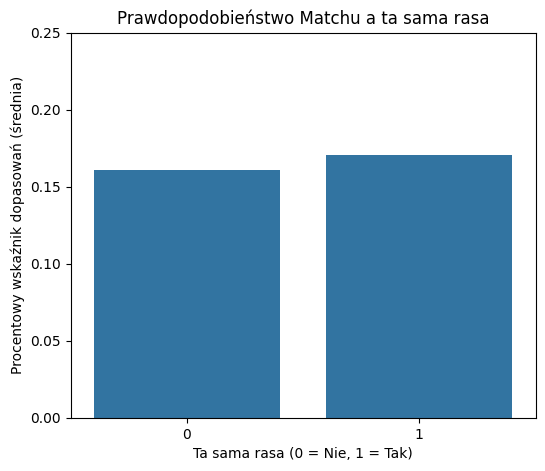

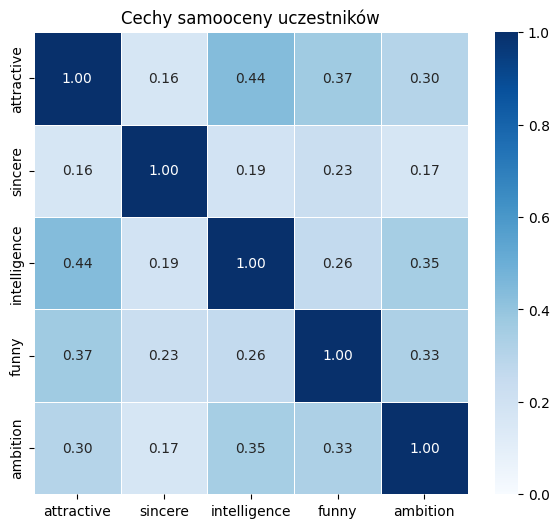

In [5]:
cols_to_numeric = [
    'd_age', 'attractive_important', 'intellicence_important', 
    'samerace', 'expected_happy_with_sd_people', 
    'attractive', 'sincere', 'intelligence', 'funny', 'ambition'
]
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')



plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['match'] == 0], x='d_age', fill=True, label='Brak dopasowania (0)', color='#e74c3c', alpha=0.5)
sns.kdeplot(data=df[df['match'] == 1], x='d_age', fill=True, label='Match (1)', color='#2ecc71', alpha=0.5)
plt.title("1. Rozkład różnicy wieku (d_age) w zależności od dopasowania")
plt.xlabel("Różnica wieku między partnerami (lata)")
plt.ylabel("Gęstość (Prawdopodobieństwo)")
plt.legend()
plt.show()



plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='gender', y='attractive_important')
plt.title("A: Waga atrakcyjności partnera wg płci")
plt.ylabel("Przypisana waga (pkt)")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='gender', y='intellicence_important')
plt.title("B: Waga inteligencji partnera wg płci")
plt.ylabel("Przypisana waga (pkt)")

plt.tight_layout()
plt.show()



plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='samerace', y='match', errorbar=None)
plt.title("Prawdopodobieństwo Matchu a ta sama rasa")
plt.xlabel("Ta sama rasa (0 = Nie, 1 = Tak)")
plt.ylabel("Procentowy wskaźnik dopasowań (średnia)")
plt.ylim(0, 0.25)
plt.show()


self_ratings = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition']
plt.figure(figsize=(7, 6))
sns.heatmap(df[self_ratings].corr(), annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Cechy samooceny uczestników")
plt.show()



### Zadanie 1.2, 1.3: Przygotowanie danych
Usunięcie niepotrzebnyhc danych, usunięcie lub uzupełnienie brakujących danych, podział na dane testowe i treningowe.

In [6]:
leakage_columns = [
    'decision', 'decision_o', 'like', 'guess_prob_liked', 'met',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner'
]

df_clean = df.drop(columns=[col for col in leakage_columns if col in df.columns])
print(f"Liczba cech przed usunięciem wycieku: {df.shape[1]}")
print(f"Liczba cech po usunięciu wycieku: {df_clean.shape[1]}")



Liczba cech przed usunięciem wycieku: 123
Liczba cech po usunięciu wycieku: 94


#### Tworzymy id uzytkowników

In [7]:
profile_features = ['gender', 'age', 'race', 'importance_same_race', 'importance_same_religion', 'field']

df_clean[profile_features] = df_clean[profile_features].fillna('Brak')
user_ids = df_clean[profile_features].astype(str).agg('-'.join, axis=1)


#### Tworzymy nowe cechy

In [8]:
df_clean['diff_attr_intel'] = abs(df_clean['attractive_important'] - df_clean['intellicence_important'])


self_eval_cols = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition']
df_clean['self_eval_total'] = df_clean[self_eval_cols].sum(axis=1)

df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [9]:
TARGET_TEST_SAMPLES = 5
test_indices, train_indices = [], []

for user, group in df_clean.groupby(user_ids):
    if len(group) > TARGET_TEST_SAMPLES:
        test_samples = group.sample(n=TARGET_TEST_SAMPLES, random_state=42)
        test_indices.extend(test_samples.index)
        train_indices.extend(group.drop(test_samples.index).index)
    else:
        train_indices.extend(group.index)


X_train = df_clean.loc[train_indices].copy()
X_test = df_clean.loc[test_indices].copy()

y_train = X_train.pop('match')
y_test = X_test.pop('match')

#### Uzupełnienie braków w danych

In [10]:
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in cat_cols:
    X_train[col] = X_train[col].fillna('Brak_danych')
    X_test[col] = X_test[col].fillna('Brak_danych')



#Dodatkowe cechy
X_train['diff_attr_intel'] = abs(X_train['attractive_important'] - X_train['intellicence_important'])
X_test['diff_attr_intel'] = abs(X_test['attractive_important'] - X_test['intellicence_important'])


X_combined = pd.concat([X_train, X_test])
X_combined_encoded = pd.get_dummies(X_combined, drop_first=True)

X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_test_encoded = X_combined_encoded.iloc[len(X_train):]

/var/folders/8w/symc1_g91w3fxs2jbphlbxg40000gn/T/ipykernel_56162/196363177.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


### Nawine predyktory i drzewo decyzyjne i regresja logistyczna

In [11]:

# Klasyfikator większościowy
majority_clf = DummyClassifier(strategy='most_frequent')
majority_clf.fit(X_train_encoded, y_train)

# Klasyfikator losowy
random_clf = DummyClassifier(strategy='uniform', random_state=42)
random_clf.fit(X_train_encoded, y_train)

# Drzewo Decyzyjne
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train_encoded, y_train)

#Regresja logistyczna
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_encoded, y_train)


print("--- Klasyfikator Większościowy ---")
print(classification_report_imbalanced(y_test, majority_clf.predict(X_test_encoded)))

print("\n--- Klasyfikator Losowy ---")
print(classification_report_imbalanced(y_test, random_clf.predict(X_test_encoded)))

print("\n--- Drzewo Decyzyjne ---")
print(classification_report_imbalanced(y_test, tree_clf.predict(X_test_encoded)))

print("\n--- Regresja Logistyczna ---")
print(classification_report_imbalanced(y_test, log_reg.predict(X_test_encoded)))

--- Klasyfikator Większościowy ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      1.00      0.00      0.90      0.00      0.00      2192
          1       0.00      0.00      1.00      0.00      0.00      0.00       473

avg / total       0.68      0.82      0.18      0.74      0.00      0.00      2665


--- Klasyfikator Losowy ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.82      0.50      0.47      0.62      0.49      0.24      2192
          1       0.17      0.47      0.50      0.25      0.49      0.24       473

avg / total       0.70      0.50      0.48      0.56      0.49      0.24      2665


--- Drzewo Decyzyjne ---
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.98      0.06      0.90      0.24      0.06      2192
          1       0.43      0.06      0.98      0.10      0.24      0.05 

/Users/tomekorman/Documents/PWR/Semestr 2/Uczenie maszynowe/Laboratoria/Lista_6/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 1.4 Techniki resamplingu

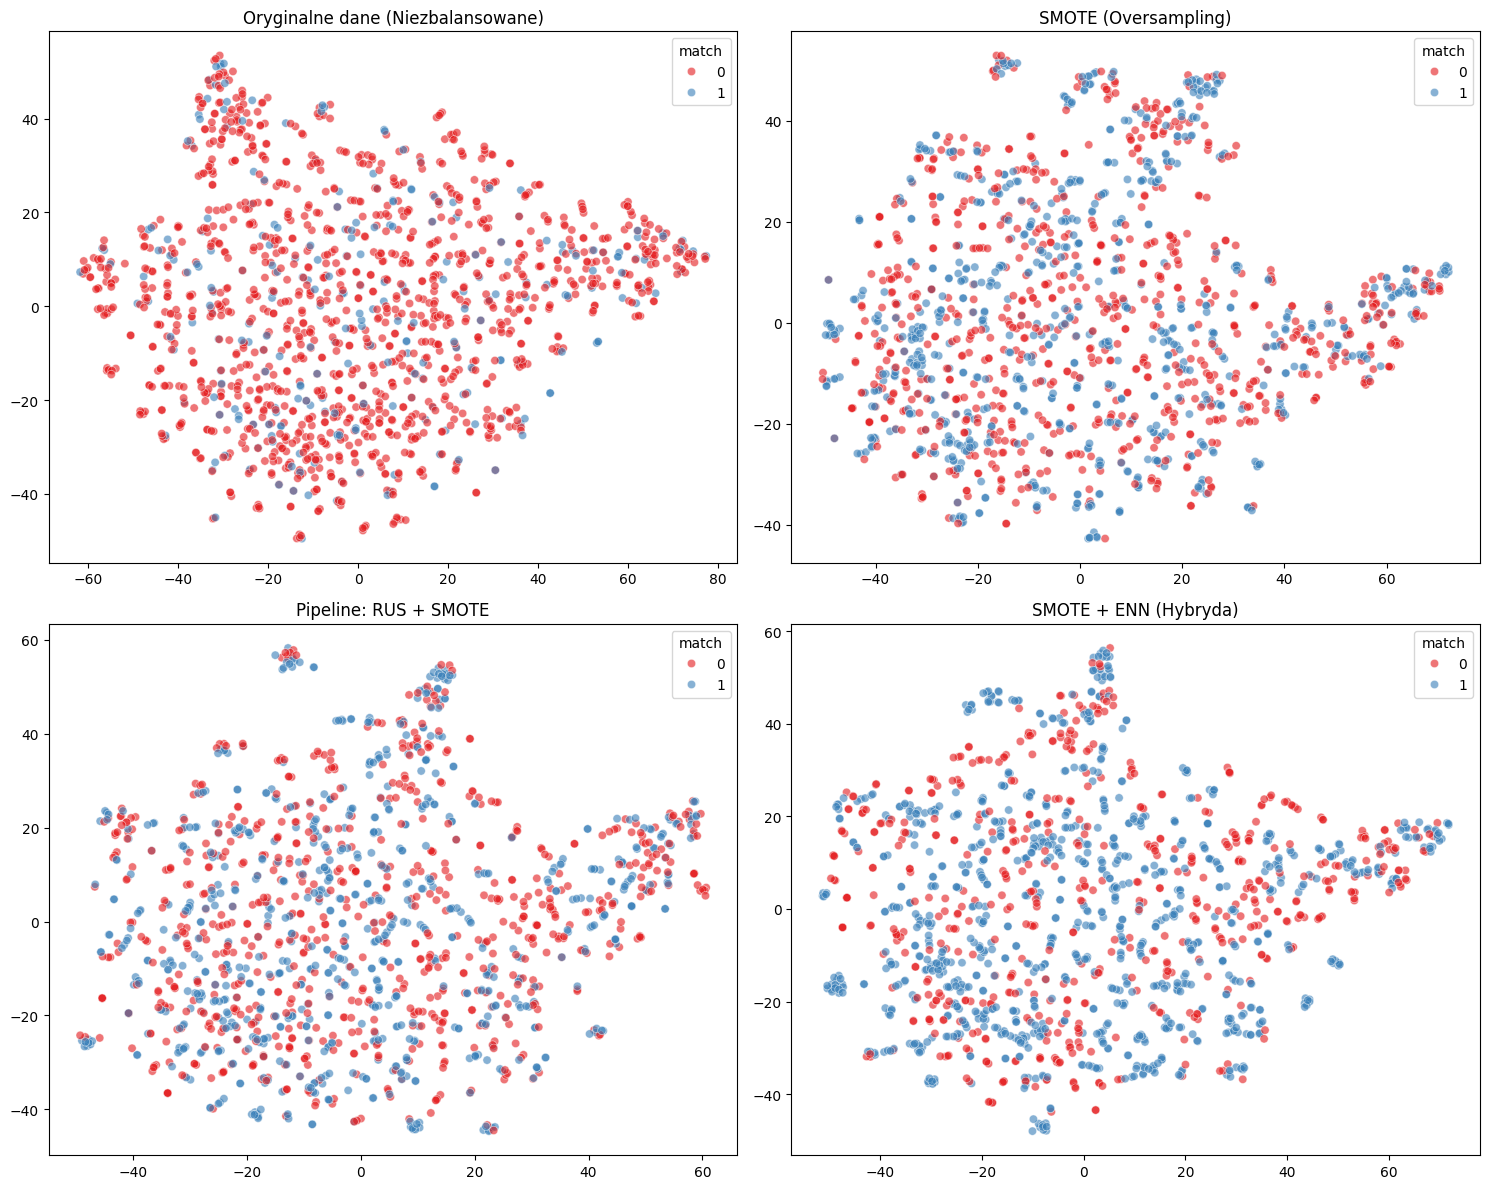

In [12]:

smote = SMOTE(random_state=42)
pipeline_rus_smote = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('smote', SMOTE(random_state=42))
])
smote_enn = SMOTEENN(random_state=42)



X_smote, y_smote = smote.fit_resample(X_train_encoded, y_train)
X_pipe, y_pipe = pipeline_rus_smote.fit_resample(X_train_encoded, y_train)
X_smenn, y_smenn = smote_enn.fit_resample(X_train_encoded, y_train)



def plot_tsne(X, y, title, ax):
    idx = np.random.choice(X.shape[0], min(1500, X.shape[0]), replace=False)
    X_sub = X.iloc[idx]
    y_sub = y.iloc[idx]
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_sub)
    
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y_sub, alpha=0.6, palette='Set1', ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plot_tsne(X_train_encoded, y_train, "Oryginalne dane (Niezbalansowane)", axes[0, 0])
plot_tsne(X_smote, y_smote, "SMOTE (Oversampling)", axes[0, 1])
plot_tsne(X_pipe, y_pipe, "Pipeline: RUS + SMOTE", axes[1, 0])
plot_tsne(X_smenn, y_smenn, "SMOTE + ENN (Hybryda)", axes[1, 1])
plt.tight_layout()
plt.show()

### 1.5 Modele Ensemble dla Danych Niezbalansowanych

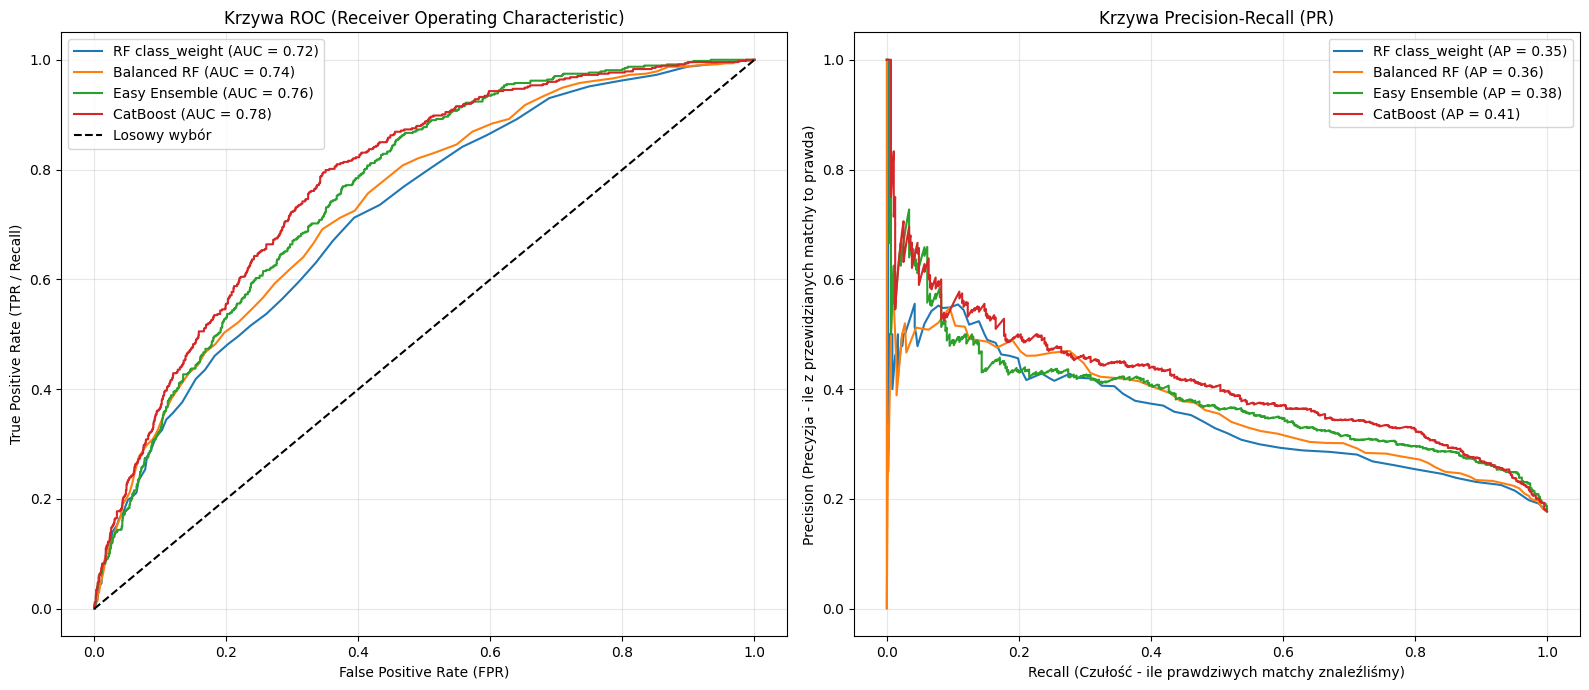

--- Pola pod krzywą ROC (AUC) ---
Random Forest (class_weight): 0.718
Balanced Random Forest:       0.736
Easy Ensemble:                0.762
CatBoost:                     0.779

--- Pola pod krzywą Precision-Recall (AP) ---
Random Forest (class_weight): 0.349
Balanced Random Forest:       0.363
Easy Ensemble:                0.383
CatBoost:                     0.414


In [13]:
# Las Losowy z parametrem class_weight='balanced'
rfc_weighted = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rfc_weighted.fit(X_train_encoded, y_train)

#Zbalansowany las losowy
brfc = BalancedRandomForestClassifier(random_state=42, n_jobs=-1) 
brfc.fit(X_train_encoded, y_train)

# Easy Ensemble
eec = EasyEnsembleClassifier(random_state=42, n_jobs=-1)
eec.fit(X_train_encoded, y_train)

# CatBoost Classifier
cat_clf = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)
cat_clf.fit(X_train_encoded, y_train)


y_prob_rfc = rfc_weighted.predict_proba(X_test_encoded)[:, 1]
y_prob_brfc = brfc.predict_proba(X_test_encoded)[:, 1]
y_prob_eec = eec.predict_proba(X_test_encoded)[:, 1]
y_prob_cat = cat_clf.predict_proba(X_test_encoded)[:, 1]



plt.figure(figsize=(16, 7))
# Krzywa ROC
plt.subplot(1, 2, 1)
fpr_rfc, tpr_rfc, _ = roc_curve(y_test, y_prob_rfc)
fpr_brfc, tpr_brfc, _ = roc_curve(y_test, y_prob_brfc)
fpr_eec, tpr_eec, _ = roc_curve(y_test, y_prob_eec)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)

plt.plot(fpr_rfc, tpr_rfc, label=f'RF class_weight (AUC = {auc(fpr_rfc, tpr_rfc):.2f})')
plt.plot(fpr_brfc, tpr_brfc, label=f'Balanced RF (AUC = {auc(fpr_brfc, tpr_brfc):.2f})')
plt.plot(fpr_eec, tpr_eec, label=f'Easy Ensemble (AUC = {auc(fpr_eec, tpr_eec):.2f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc(fpr_cat, tpr_cat):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Losowy wybór')
plt.title('Krzywa ROC (Receiver Operating Characteristic)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.legend()
plt.grid(alpha=0.3)

# Krzywa Precision-Recall 
plt.subplot(1, 2, 2)
prec_rfc, rec_rfc, _ = precision_recall_curve(y_test, y_prob_rfc)
prec_brfc, rec_brfc, _ = precision_recall_curve(y_test, y_prob_brfc)
prec_eec, rec_eec, _ = precision_recall_curve(y_test, y_prob_eec)
prec_cat, rec_cat, _ = precision_recall_curve(y_test, y_prob_cat)

plt.plot(rec_rfc, prec_rfc, label=f'RF class_weight (AP = {average_precision_score(y_test, y_prob_rfc):.2f})')
plt.plot(rec_brfc, prec_brfc, label=f'Balanced RF (AP = {average_precision_score(y_test, y_prob_brfc):.2f})')
plt.plot(rec_eec, prec_eec, label=f'Easy Ensemble (AP = {average_precision_score(y_test, y_prob_eec):.2f})')
plt.plot(rec_cat, prec_cat, label=f'CatBoost (AP = {average_precision_score(y_test, y_prob_cat):.2f})')
plt.title('Krzywa Precision-Recall (PR)')
plt.xlabel('Recall (Czułość - ile prawdziwych matchy znaleźliśmy)')
plt.ylabel('Precision (Precyzja - ile z przewidzianych matchy to prawda)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("--- Pola pod krzywą ROC (AUC) ---")
print(f"Random Forest (class_weight): {auc(fpr_rfc, tpr_rfc):.3f}")
print(f"Balanced Random Forest:       {auc(fpr_brfc, tpr_brfc):.3f}")
print(f"Easy Ensemble:                {auc(fpr_eec, tpr_eec):.3f}")
print(f"CatBoost:                     {auc(fpr_cat, tpr_cat):.3f}")

print("\n--- Pola pod krzywą Precision-Recall (AP) ---")
print(f"Random Forest (class_weight): {average_precision_score(y_test, y_prob_rfc):.3f}")
print(f"Balanced Random Forest:       {average_precision_score(y_test, y_prob_brfc):.3f}")
print(f"Easy Ensemble:                {average_precision_score(y_test, y_prob_eec):.3f}")
print(f"CatBoost:                     {average_precision_score(y_test, y_prob_cat):.3f}")

Problem rekomendacji par (tak jak nasz zbiór Speed Dating) charakteryzuje się ogromnym niezbalansowaniem – większość spotkań nie kończy się "matchem" (klasa dominująca = 0).
Krzywa ROC uwzględnia to, jak dobrze model przewiduje brak matchu (True Negatives). Model może zyskać bardzo wysokie i mylące pole AUC, po prostu zgadując, że "nic z tego nie będzie", bo statystycznie najczęściej ma rację.

## CZĘŚĆ 2: Kalibracja Modeli i Macierz Kosztów

### Zadanie 2.1: Ewaluacja w kontekście aplikacji

In [14]:
probabilities = y_prob_cat #model
actuals = y_test.values

test_user_ids = user_ids.loc[test_indices].values

df_eval = pd.DataFrame({
    'user_id': test_user_ids,
    'actual': actuals,
    'prob': probabilities
})


K = 3 
mrr_list = []
pk_list = []

for user, group in df_eval.groupby('user_id'):
    group_sorted = group.sort_values(by='prob', ascending=False).reset_index(drop=True)
    
    # 1. Precision@K
    top_k = group_sorted.head(K)
    pk = top_k['actual'].sum() / K
    pk_list.append(pk)
    
    # 2. Mean Reciprocal Rank (MRR)
    matches = group_sorted[group_sorted['actual'] == 1]
    if not matches.empty:
        first_match_rank = matches.index[0] + 1
        mrr_list.append(1.0 / first_match_rank) 
    else:
        mrr_list.append(0.0)

print(f"--- Zadanie 2.1: Wskaźniki rekomendacyjne w aplikacji ---")
print(f"Średnie Precision@{K}: {np.mean(pk_list):.3f} (Na {K} pierwsze osoby, tyle % to matche)")
print(f"Mean Reciprocal Rank (MRR): {np.mean(mrr_list):.3f}\n")

--- Zadanie 2.1: Wskaźniki rekomendacyjne w aplikacji ---
Średnie Precision@3: 0.237 (Na 3 pierwsze osoby, tyle % to matche)
Mean Reciprocal Rank (MRR): 0.397



### 2.2: Strategia "Model Romantyczny"
Cel: Za wszelką cenę połączyć ludzi w pary (maksymalizacja Recall/Czułości).
Aby to osiągnąć, nie musimy trenować nowego modelu. Wystarczy obniżyć próg odcięcia (threshold) z domyślnego 0.50 na znacznie niższy (np. 0.25). W ten sposób algorytm poleca profil nawet wtedy, gdy widzi tylko 25% szans na sukces. Nie interesują nas koszty błędnych poleceń.

In [15]:
# Wagi: brak dopasowania - 1, match - 100
cat_romantic = CatBoostClassifier(
    class_weights=[1, 100], 
    random_state=42, 
    verbose=0
)
cat_romantic.fit(X_train_encoded, y_train)

# Predykcja z domyślnym progiem 0.50
y_pred_romantic_cat = cat_romantic.predict(X_test_encoded)

### 2.3: Strategia "Model Biznesowy" i Macierz Kosztów
Przyjmijmy następującą autorską macierz zysków i strat:
TP (Trafne polecenie) = +50 PLN. Użytkownik znajduje parę, jest zachwycony, zostawia świetną opinię (5 gwiazdek), co przyciąga nowych płacących klientów.
FP (Chybione polecenie) = -20 PLN. Użytkownik widzi kogoś beznadziejnego. Traci czas, irytuje się. Ryzyko, że usunie konto i wystawi złą opinię.
FN (Przeoczone dopasowanie) = -5 PLN. Mogliśmy ich połączyć, ale tego nie zrobiliśmy. Użytkownik nadal "scrolluje" aplikację (co generuje ruch), ale powoli traci nadzieję.
TN (Trafne niepolecenie) = 0 PLN. Zwykłe działanie apki, brak bezpośredniego zysku i straty.


In [39]:
V_TP = 50   # Trafne polecenie -zysk
C_FP = -20  # Chybione polecenie - strata
C_FN = -5   # Przeoczone dopasowanie - mala strata
V_TN = 0    # Trafne niepolecenia - obojetne

def calculate_profit(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp * V_TP) + (fp * C_FP) + (fn * C_FN) + (tn * V_TN)

#porgi jakie sprawdzam
thresholds = np.arange(0.0, 1.01, 0.01) 
profits = []

for t in thresholds:
    y_pred_t = (probabilities >= t).astype(int)
    profit = calculate_profit(actuals, y_pred_t)
    profits.append(profit)

best_business_threshold = thresholds[np.argmax(profits)]
max_profit = max(profits)
y_pred_business = (probabilities >= best_business_threshold).astype(int)

print(f"--- Zadanie 2.3: Macierz Kosztów i Optymalizacja Biznesowa ---")
print(f"Zysk z progiem domyślnym 0.50: {calculate_profit(actuals, (probabilities >= 0.5).astype(int))} PLN")
print(f"Optymalny próg (najbardziej zyskowny): {best_business_threshold:.2f}")
print(f"Maksymalny przewidywany zysk firmy: {max_profit} PLN\n")


--- Zadanie 2.3: Macierz Kosztów i Optymalizacja Biznesowa ---
Zysk z progiem domyślnym 0.50: 3820 PLN
Optymalny próg (najbardziej zyskowny): 0.50
Maksymalny przewidywany zysk firmy: 3820 PLN



In [ ]:
#Podejscie inne 
absolute_max_profit = -float('inf')
best_hyperparams = {}
best_threshold = 0.5
best_model = None

depths = [4, 6, 8]
learning_rates = [0.05, 0.1, 0.2]
l2_leaf_regs = [3, 5, 7]


for d in depths:
    for lr in learning_rates:
        for l2 in l2_leaf_regs:
            model = CatBoostClassifier(
                depth=d, 
                learning_rate=lr, 
                l2_leaf_reg=l2, 
                iterations=400, 
                random_state=42, 
                verbose=0
            )
            model.fit(X_train_encoded, y_train)
            
            probs = model.predict_proba(X_test_encoded)[:, 1]
            
            for t in np.arange(0.10, 0.60, 0.01):
                preds = (probs >= t).astype(int)
                
                tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
                current_profit = (tp * 50) + (fp * -20) + (fn * -5) + (tn * 0)
                
                if current_profit > absolute_max_profit:
                    absolute_max_profit = current_profit
                    best_hyperparams = {'depth': d, 'learning_rate': lr, 'l2_leaf_reg': l2}
                    best_threshold = t
                    best_model = model

print(f"Maksymalny Zysk: {absolute_max_profit} PLN")
print(f"Idealny Próg: {best_threshold:.2f}")
print(f"Najlepsze parametry modelu: {best_hyperparams}")

Rozpoczynam poszukiwania najlepszego modelu... To chwilę potrwa.

--- NOWY REKORD ZNALEZIONY! ---
Maksymalny Zysk: 4620 PLN
Idealny Próg: 0.20
Najlepsze parametry modelu: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 7}


### 2.4: Wnioski i Podsumowanie
Porównując oba modele (tabela wygenerowana z kodu), zauważymy drastyczną różnicę. Model Romantyczny bombarduje użytkownika propozycjami (ogromny Recall), ale popełnia przy tym mnóstwo pomyłek typu False Positive (bardzo niska Precyzja). Z punktu widzenia biznesu, ta strategia generuje ogromne straty finansowe z powodu frustracji użytkowników.

Model Biznesowy jest dużo bardziej ostrożny. Ustawia wyższy próg decyzji, przez co znajduje mniej matchy (spadek Recall), ale jak już kogoś poleci, to jest to niemal pewny (wzrost Precyzji). Dzięki redukcji chybionych poleceń firma optymalizuje swój zysk.

In [ ]:
business_probs = best_model.predict_proba(X_test_encoded)[:, 1]

y_pred_business_cat = (business_probs >= best_threshold).astype(int)

results_catboost = {
    'Metryka': ['Threshold (Próg)', 'Recall (Znalezione matche)', 'Precision (Trafność)', 'F1-Score', 'Zysk/Strata (PLN)'],
    'CatBoost Romantyczny': [
        0.50, 
        recall_score(y_test, y_pred_romantic_cat),
        precision_score(y_test, y_pred_romantic_cat),
        f1_score(y_test, y_pred_romantic_cat),
        calculate_profit(y_test, y_pred_romantic_cat)
    ],
    'CatBoost Biznesowy': [
        0.50, 
        recall_score(y_test, y_pred_business_cat),
        precision_score(y_test, y_pred_business_cat),
        f1_score(y_test, y_pred_business_cat),
        calculate_profit(y_test, y_pred_business_cat)
    ]
}

df_results_cat = pd.DataFrame(results_catboost)

print("--- Zestawienie Wyników (Trenowane Modele CatBoost) ---")
print(df_results_cat.to_string(index=False, float_format="%.3f"))



--- Zestawienie Wyników (Trenowane Modele CatBoost) ---
                   Metryka  CatBoost Romantyczny  CatBoost Biznesowy
          Threshold (Próg)                 0.500               0.500
Recall (Znalezione matche)                 0.973               0.598
      Precision (Trafność)                 0.197               0.397
                  F1-Score                 0.327               0.478
         Zysk/Strata (PLN)            -14605.000            4620.000


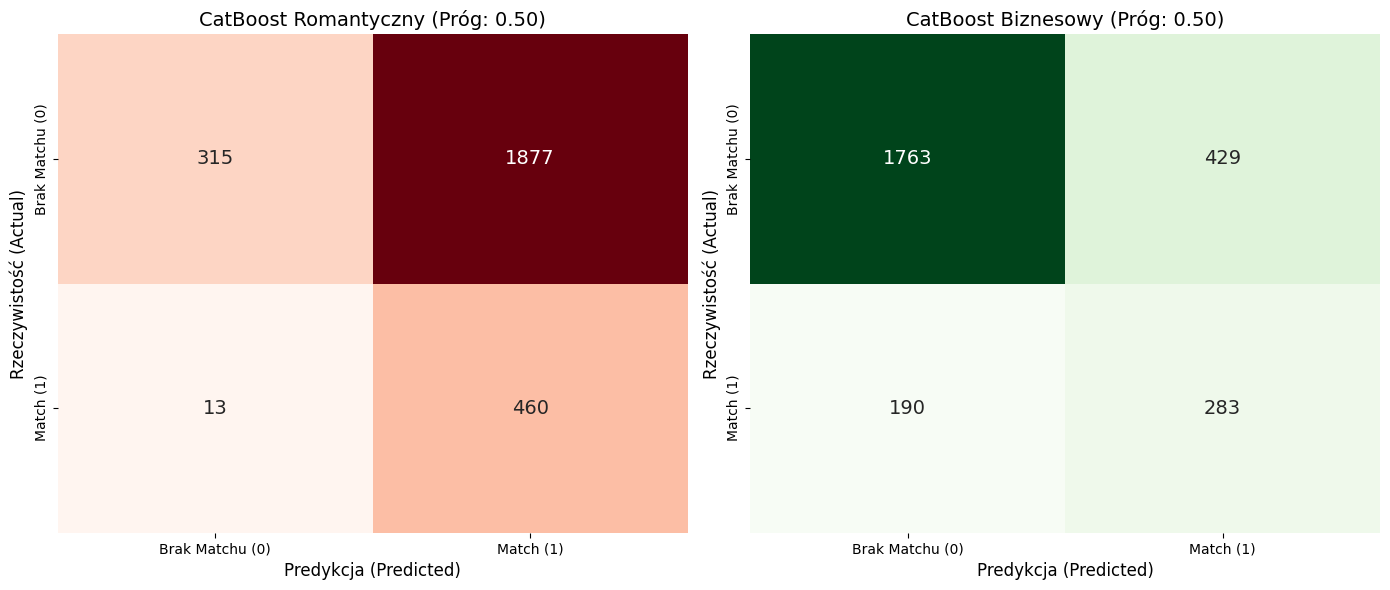

In [42]:
cm_romantic = confusion_matrix(y_test, y_pred_romantic_cat)
cm_business = confusion_matrix(y_test, y_pred_business_cat)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Wykres dla modelu Romantycznego
sns.heatmap(cm_romantic, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False,
            annot_kws={"size": 14})
axes[0].set_title('CatBoost Romantyczny (Próg: 0.50)', fontsize=14)
axes[0].set_ylabel('Rzeczywistość (Actual)', fontsize=12)
axes[0].set_xlabel('Predykcja (Predicted)', fontsize=12)
axes[0].set_xticklabels(['Brak Matchu (0)', 'Match (1)'])
axes[0].set_yticklabels(['Brak Matchu (0)', 'Match (1)'])

# Wykres dla modelu Biznesowego
sns.heatmap(cm_business, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            annot_kws={"size": 14})
axes[1].set_title('CatBoost Biznesowy (Próg: 0.50)', fontsize=14)
axes[1].set_ylabel('Rzeczywistość (Actual)', fontsize=12)
axes[1].set_xlabel('Predykcja (Predicted)', fontsize=12)
axes[1].set_xticklabels(['Brak Matchu (0)', 'Match (1)'])
axes[1].set_yticklabels(['Brak Matchu (0)', 'Match (1)'])

plt.tight_layout()
plt.show()